In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [2]:
print(tf.__version__)


2.20.0


In [10]:
import tensorflow as tf 

In [11]:
fashion_df = tf.keras.datasets.fashion_mnist.load_data()

In [12]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_df

X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [13]:
tf.random.set_seed(42)

Model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28,28]),
    tf.keras.layers.Dense(300,activation="relu"),
    tf.keras.layers.Dense(100,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])




In [14]:
Model.layers

Compiling the model 

In [15]:
Model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

In [16]:
history = Model.fit(X_train,y_train,epochs=30,validation_data=(X_valid,y_valid))


Epoch 1/30
1719/1719 [==============================] - 11s 6ms/step - loss: 0.4857 - accuracy: 0.8259 - val_loss: 0.4145 - val_accuracy: 0.8376
Epoch 2/30
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3652 - accuracy: 0.8673 - val_loss: 0.3884 - val_accuracy: 0.8536
Epoch 3/30
1719/1719 [==============================] - 9s 5ms/step - loss: 0.3285 - accuracy: 0.8786 - val_loss: 0.3463 - val_accuracy: 0.8732
Epoch 4/30
 997/1719 [================>.............] - ETA: 3s - loss: 0.3003 - accuracy: 0.8895

KeyboardInterrupt: 

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


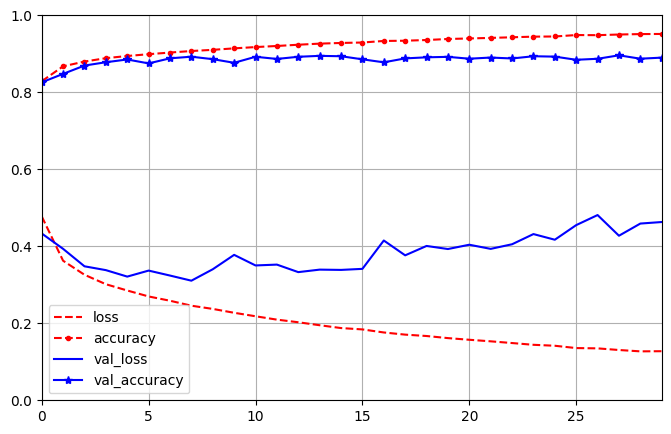

In [ ]:


import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 29], ylim=[0, 1], grid=True,
    style=["r--", "r--.", "b-", "b-*"]
)
plt.show()

In [ ]:
Model.evaluate(X_test,y_test)

313/313 [==============================] - 1s 2ms/step - loss: 0.4807 - accuracy: 0.8863


[0.4807373881340027, 0.8863000273704529]

Save and loading the best model